# Introduction to Hyrax

In this notebook we'll work through several core aspects of Hyrax that will provide a foundation for additional exploration. 

Some of the points covered here include:
* A custom dataset class for ZTF alerts stored on Delta in .npy format.
* Basic training and inference of a built in, unsupervised model, `HyraxAutoencoderV2`.
* Dimensional reduction of inference results.
* Simple visualization using Hyrax's data system.
* Writing a custom supervised model (wrapper over ResNet18).
* Demonstration of simple analysis of supervised model performance.

Becuase we are focusing on using the Hyrax package as platform for rapid experimentation, it should come as no surprise that we'll begin by importing and creating an instance of a Hyrax object.

In [9]:
from hyrax import Hyrax
import numpy as np
import matplotlib.pyplot as plt

h = Hyrax()

## ZTF Alert Dataset class

The following class can be reused for any Hyrax-based model development.
The class expects that the data will be in a single directory and a collection of .npy files with the naming scheme `ZTF[YY]_[object_id]_alert_[N].npy`.

Note: There are two modes of operation - "all" and "latest".
* "all": Every .npy in the directory is treated as a distinct data sample. 
* "latest": Only the last alert for a given object id will be utilized.

In [ ]:
import os

import numpy as np
import torch
from hyrax.datasets import HyraxDataset

CLASS_NAMES = ["AGN", "Tidal Disruption Event", "SN II", "SN IIP", "SN Ia", "SN IIn", "SN Ib", "SN Ic", "Cataclysmic"]
CLASS_TO_INDEX = {class_name: indx for indx, class_name in enumerate(CLASS_NAMES)}

class LocalZTFAlertDataset(HyraxDataset):
    def __init__(self, config, data_location):
        self.data_location = data_location

        self.file_set = "latest"
        
        # get the list of files
        if self.file_set == "latest":
            self.file_names = sorted(self._latest_alert_per_object())
        elif self.file_set == "all":
            self.file_names = sorted([f for f in os.listdir(self.data_location) if f.endswith(".npy")])

        # This is a file cache, allowing us to load a file once to retrieve each
        # separate field. This decreases training and inference time slightly.
        # Hyrax's internal caching will store data across epochs for faster training.
        self.raw_files = {}

        self.class_name_to_index = {name: indx for indx, name in enumerate(CLASS_NAMES)}
        
        super().__init__(config)


    def _latest_alert_per_object(self):
        """Scan `self.data_location` and return a list of full paths, 
        keep only the latest alert path for each unique object_id.
        """
        latest = {}  # object_id -> (N, filename)
    
        with os.scandir(self.data_location) as it:
            for entry in it:
                name = entry.name
                if not name.endswith('.npy'):
                    continue
    
                # Split off the ".npy" and the "_alert_<N>" suffix
                try:
                    base, n_str = name[:-4].rsplit('_alert_', 1)
                    n = int(n_str)
                except ValueError:
                    continue  # skip files that don't match the expected pattern
    
                current = latest.get(base)
                if current is None or n > current[0]:
                    latest[base] = (n, name)
    
        return [os.path.join(self.data_location, name) for _, name in latest.values()]
    
    def _load_file(self, index):
        """Return the data at `index` if it's in the dictionary.
        Otherwise load the file and return the value.
        """
        return self.raw_files.setdefault(
            index,
            np.load(os.path.join(self.data_location, self.file_names[index]), allow_pickle=True).item()
        )

    def get_metadata(self, index) -> np.ndarray:
        """Retrieve metadata from the alert at the specified index
        """
        return np.asarray(self._load_file(index).get("metadata"))

    def get_image(self, index) -> np.ndarray:
        """Retrieve the image at the specified index.
        NOTE: A naive normalization is applied - review for your use case! 
        """
        image = self._load_file(index).get("image")
        i1 = 0
        i2 = 63
        image = image[:, i1:i2, i1:i2]

        # rescale image. Note image has shape = (3, 63, 63)
        for i in range(3):
            band = image[i, :, :]
            
            # Calculate percentiles just for this single band
            vmin = np.percentile(band, 2)
            vmax = np.percentile(band, 98)
            
            # Clip and normalize this band
            clipped = np.clip(band, vmin, vmax)
            
            # Prevent divide-by-zero if a band is completely flat
            if vmax > vmin:
                image[i, :, :] = (clipped - vmin) / (vmax - vmin)
            else:
                image[i, :, :] = 0.0

        return np.asarray(image)

    def augment_image(self, image, index, rnd_seed):
        """NOTE: THIS IS A PLACEHOLDER METHOD, YOU SHOULD CHANGE IT FOR YOUR NEEDS!
        
        When balancing the dataset so that each class is seen roughly equally by
        the model during training, a given image may be used multiple times.
        This function can be used to slightly change the image (e.g. rotate, jitter)
        so that the model isn't trained on multiple identical images.
        """
        return image

    def get_target(self, index) -> int:
        """Return the index of the target class name from the list
        of class names.
        """
        original_class = self._load_file(index).get("target")
        
        return self.class_name_to_index.get(original_class, -1)

    def get_target_as_one_hot(self, index) -> np.ndarray:
        """Return a one-hot target class ndarray
        """
        target = np.zeros(len(CLASS_NAMES))
        original_class = self._load_file(index).get("target")
        target[CLASS_TO_INDEX[original_class]] = 1

        return target
    
    def get_target_friendly_name(self, index) -> str:
        """ Return the human readable class name. e.g. "AGN"
        """
        return self._load_file(index).get("target")

    def get_obj_id(self, index) -> str:
        """Retrieve object ID at the specified index.
        NOTE: Hyrax *requires* the object id to be a string.
        """
        return str(self._load_file(index).get("obj_id"))

    def display(self, index):
        """Used by the visualization tool to plot image cutouts
        """
        import matplotlib.figure as mpl_figure

        image = self.get_image(index)
        class_name = self.get_target_friendly_name(index)
        arr = np.transpose(image, (1, 2, 0))

        # Display the image with matplotlib, removing axes and adding a title with the index
        fig = mpl_figure.Figure(figsize=(3, 3))
        ax = fig.add_subplot(111)
        ax.imshow(arr)
        # turn off the x and y axis
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"Index: {index}, Class: {class_name}" if index is not None else "No selection")
        return fig
    
    
    def __len__(self):
        # Return the total number of items in the dataset
        return len(self.file_names)

### Defining what data to use

To tell Hyrax what data to work with, you provide a data request. An example for training is shown below.

In [73]:
data_request = {
    "train": {  # <- The "data group" name. Different Hyrax verbs expect different data groups to be defined.
        "data": {  # <- The "friendly name" of the data set. A data group can include many datasets. 
            "dataset_class": "LocalZTFAlertDataset",  # <- The name of the class that will load the data
            "data_location": "/work/nvme/bcrv/bborder/data/fixed_data",
            "primary_id_field": "obj_id",  # <- The data field that provides a unique id for each data sample
            "fields": ["image", "target"],  # <- The list of specific fields to load from this dataset
            "augment": ["image"],  # <- Optional, the field(s) that will be augmented if rebalancing the dataset.
        },
    },
    "validate": {
        "data": {
            "dataset_class": "LocalZTFAlertDataset",
            "data_location": "/work/nvme/bcrv/bborder/data/fixed_data",
            "primary_id_field": "obj_id",
            "fields": ["image", "target"],
            "augment": ["image"]
        },
    },
}

h.set_config("data_request", data_request)

split = {
    "train": 0.8,
    "validate": 0.2,
}
h.set_config("split", split)

# Uncomment this to balance the dataset. Training startup takes longer,
# but this will ensure that roughly the same number of each class are 
# shown to the model during training.
# balance = {
#     "field": "target",
#     "groups": ["train"]
# }
# h.set_config("balance", balance)

### Simple check of the target class counts

Just a quick check that one might use to verify expectations about class distributions. 
This isn't particularly efficient, because it requires reading _every_ file, but it shows that the classes are quite unbalanced.

In [68]:
from tqdm import tqdm
ds = h.prepare()
counts = {}
for i in tqdm(range(len(ds['train']))):
    target = ds['train'][i]['data']['target']
    counts[target] = counts.get(target, 0) + 1
counts

[2026-07-29 16:56:00,469 hyrax.verbs.prepare:INFO] Finished Prepare
100%|██████████| 9460/9460 [00:41<00:00, 227.04it/s]


{8: 367, 0: 1741, 1: 54, 4: 5655, 7: 142, 3: 576, 2: 607, 5: 194, 6: 124}

## Train a model

Here we'll train the built in `HyraxAutoencoderV2` model.
Note that we also update the configuration setting the number of epochs for training and the batch size to use.

In [ ]:
h.set_config("model.name", "HyraxAutoencoderV2")
h.set_config("train.epochs", 10)
h.set_config("data_loader.batch_size", 64)
# h.set_config("data_loader.num_workers", 4)  # For faster training, set this equal to the number of CPUs available.
# h.set_config("data_loader.prefetch_factor", 8)  # For faster training, set this >2 when `num_workers` is set above.

model = h.train()

## Predict with a model
Note that we update the data request here. Internally Hhyrax merges this data request with the previous. But only the necessary dataset classes will be instantiated for a given Hyrax verb. 

In [6]:
data_request = {
    "infer": {
        "data": {
            "dataset_class": "LocalZTFAlertDataset",
            "data_location": "/work/nvme/bcrv/bborder/data/fixed_data",
            "primary_id_field": "obj_id",
            "fields": ["image"],
        },
    },
}

h.set_config("data_request", data_request)

[2026-07-29 16:31:34,457 hyrax.config_utils:WARNING] Runtime config contains key or section 'infer' which has no default defined. All configuration keys and sections must be defined in /u/drewoldag/.conda/envs/hyrax/lib/python3.13/site-packages/hyrax/hyrax_default_config.toml


In [12]:
h.set_config("data_loader.batch_size", 1024)
results = h.infer()

[2026-07-29 16:04:27,993 hyrax.models.model_registry:INFO] Setting model's self.optimizer from config: torch.optim.SGD with arguments: {'lr': 0.001, 'momentum': 0.9}.
[2026-07-29 16:04:27,994 hyrax.models.model_registry:INFO] Setting model's self.criterion from config: torch.nn.CrossEntropyLoss with default arguments.
[2026-07-29 16:04:27,994 hyrax.models.model_registry:INFO] Setting model's self.scheduler from config: torch.optim.lr_scheduler.ExponentialLR
with arguments: {'gamma': 1}.
[2026-07-29 16:04:27,995 hyrax.verbs.infer:INFO] Inference model: HyraxAutoencoderV2
[2026-07-29 16:04:27,995 hyrax.verbs.infer:INFO] Inference dataset(s):
{'infer': Name: data (primary dataset)
  Dataset class: LocalZTFAlertDataset
  Data location: /work/nvme/bcrv/bborder/data/fixed_data
  Selected items: 9460
  Primary ID field: obj_id
  Requested fields: image
}
2026-07-29 16:04:27,996 ignite.distributed.auto.auto_dataloader INFO: Use data loader kwargs for dataset '<torch.utils.data.da': 
	{'sampler

 10%|#         | 1/10 [00:00<?, ?it/s]

[2026-07-29 16:05:25,746 hyrax.pytorch_ignite:INFO] Total evaluation time: 57.70[s]
[2026-07-29 16:05:25,747 hyrax.datasets.result_dataset:INFO] Optimizing Lance table after 10 batches
[2026-07-29 16:05:26,194 hyrax.datasets.result_dataset:INFO] Lance table optimization complete
[2026-07-29 16:05:26,296 hyrax.verbs.infer:INFO] Inference Complete.


## Reduce dimensionality
The output of the `HyraxAutoencoderV2` model is a 64d vector (which is a bit challenging to visualize).
Hyrax has multiple dimensional reduction algorithms built in which make it tractible to visualize the output of models.

In this example, we'll use `UMAP` to reduce the dimensionality from 64d to 2d for simple plotting.

In [13]:
umap_results = h.reduce_dimensions(algorithm="umap")

[2026-07-29 16:05:38,030 hyrax.verbs.reduce_dimensions:INFO] Saving reduction results using umap to /projects/bcrv/drewoldag/results/20260729-160538-umap-5ZJ7
[2026-07-29 16:05:38,089 hyrax.verbs.reduce_dimensions:INFO] No model_path specified. A new model will be fitted.
[2026-07-29 16:05:38,090 hyrax.verbs.reduction_algorithms.umap:INFO] Fitting the UMAP
[2026-07-29 16:05:48,732 hyrax.verbs.reduce_dimensions:INFO] Saving fitted umap reducer to result directory


Creating lower dimensional representation using UMAP::   0%|          | 0/10 [00:00<?, ?it/s]

[2026-07-29 16:06:07,386 hyrax.datasets.result_dataset:INFO] Optimizing Lance table after 10 batches
[2026-07-29 16:06:07,443 hyrax.datasets.result_dataset:INFO] Lance table optimization complete
[2026-07-29 16:06:07,443 hyrax.verbs.reduce_dimensions:INFO] Finished transforming all data with umap


### Simple visualization
Let's explore the results of the dimensional reduction
Note: we combine two datasets in under a single data group 1) the UMAP output and 2) the original ZTF alert dataset in this data request. 

Combining datasets in a single data group allows for simple multimodal operations both manually (as shown here) as well as for training and inference. 
When multiple datasets are requested in the same data group, then must be "index aligned". i.e. retrieving index `i` from one maps directly to the same object in the other dataset.
For more complex joins of datasets of different modalities, we recommend first crossmatching with LSDB and exporting the catalog as Lance files.

In [7]:
# Use umap output plus the target class of the original data to create a scatter plot, hope for separability
from hyrax.config_utils import find_most_recent_results_dir

data_request_definition = {
    "explore": {
        "umap": {
            "dataset_class": "ResultDataset",
            "data_location": str(find_most_recent_results_dir(h.config, "umap")),
            "primary_id_field": "object_id",
            "fields": ["data"],
        },
        "ztf_data": {
            "dataset_class": "LocalZTFAlertDataset",
            "data_location": "/work/nvme/bcrv/bborder/data/fixed_data",
            "fields": ["image", "target", "target_friendly_name"],
        },
    },

}
h.set_config("data_request", data_request_definition)

ds = h.prepare()

[2026-07-29 16:31:41,816 hyrax.config_utils:WARNING] Runtime config contains key or section 'explore' which has no default defined. All configuration keys and sections must be defined in /u/drewoldag/.conda/envs/hyrax/lib/python3.13/site-packages/hyrax/hyrax_default_config.toml


In [15]:
# We can index into the working dataset, `ds` to see all of the available data for a given index
ds['explore'][132]

{'umap': {'data': array([ 5.7712526, -2.7783937], dtype=float32)},
 'ztf_data': {'image': array([[[0.2867264 , 0.39493343, 0.4305322 , ..., 0.26473358,
           0.35162085, 0.17458878],
          [0.6886353 , 0.5929875 , 0.60921115, ..., 0.3359831 ,
           0.12510227, 0.3480695 ],
          [1.        , 1.        , 1.        , ..., 0.23165397,
           0.34483406, 0.03597126],
          ...,
          [0.46410704, 0.        , 0.48460323, ..., 0.12441201,
           0.22272986, 0.45630375],
          [0.2322366 , 0.        , 0.47707325, ..., 0.35271505,
           0.15810992, 0.41154563],
          [0.41498485, 0.0979756 , 0.12590621, ..., 0.17715997,
           0.46598795, 0.19446728]],
  
         [[0.16472809, 0.27236262, 0.2570065 , ..., 0.06228138,
           0.00386447, 0.04623767],
          [0.5249817 , 0.53978026, 0.5561575 , ..., 0.0683578 ,
           0.0625424 , 0.06960796],
          [1.        , 1.        , 1.        , ..., 0.0675895 ,
           0.0841364 , 0.0584

In [9]:
# Here we convert the datasets into a form that is more convenient for manual plotting
from tqdm import tqdm
x = np.empty(len(ds['explore']))  # UMAP dimension 1
y = np.empty(len(ds['explore']))  # UMAP dimension 2
c = np.empty(len(ds['explore']))  # Known class of object

for i in tqdm(range(len(ds['explore']))):
    x[i], y[i] = ds['explore'][i]['umap']['data']
    c[i] = ds['explore'][i]['ztf_data']['target']


100%|██████████| 9460/9460 [01:59<00:00, 79.09it/s] 


### Some scatter plots
The results of inference+umap'ing aren't so great. With the built in model we don't see any separability between the classes.

There are several possible reasons for this including: incorrect normalization of the images in the dataset class, the images themselves are too similiar for the model to identify differences, or perhaps the dataset is sufficiently unbalanced that the model is struggling.

In the collection of 9 scatter plots below, we would hope to see 1 distinct clump for each class, but what we see is that all classes occupy the same UMAP space.

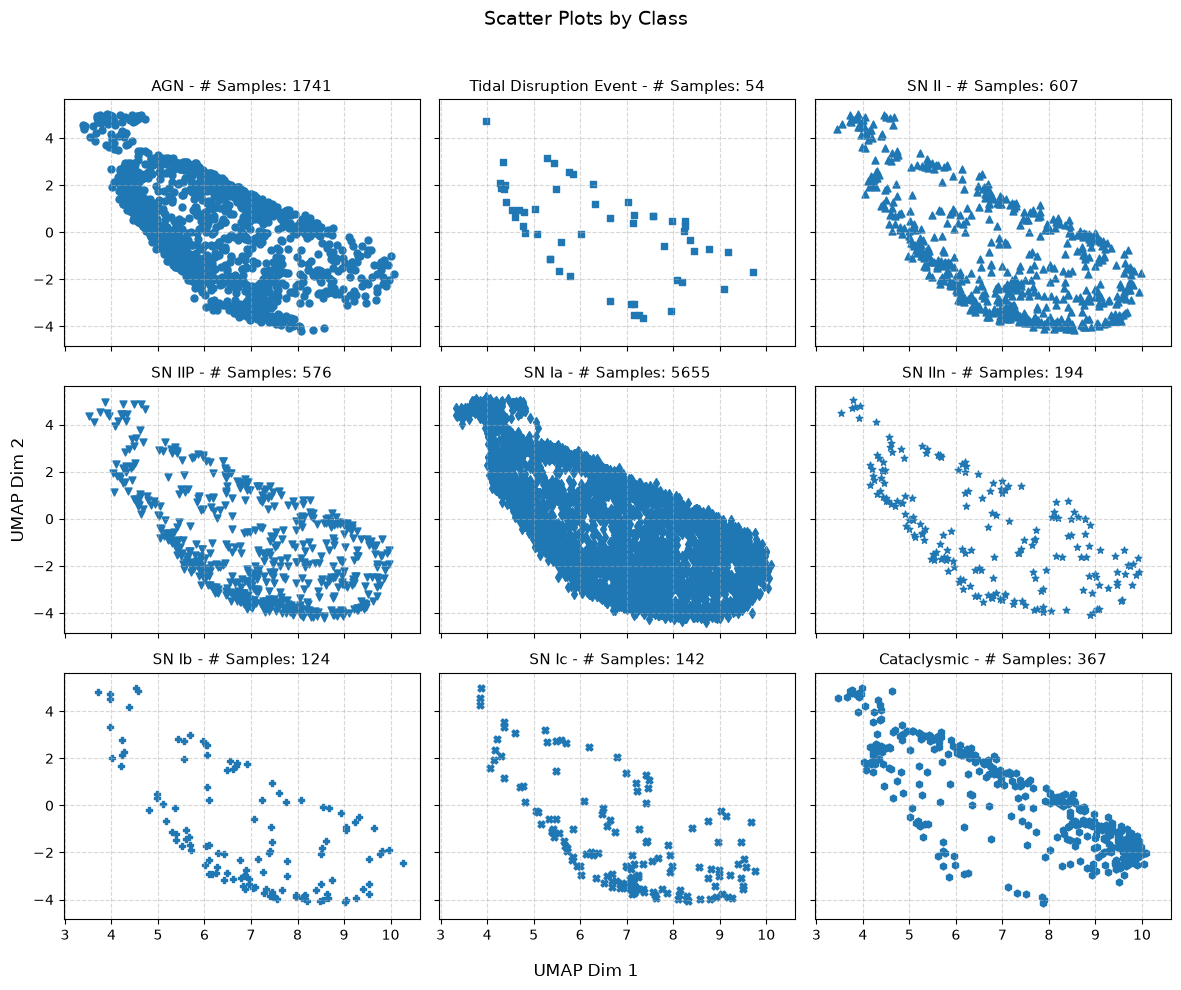

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Map 9 unique marker types to the 9 groups
marker_mapping = {
    0 : "o",  # Circle
    1 : "s",  # Square
    2 : "^",  # Triangle Up
    3 : "v",  # Triangle Down
    4 : "d",  # Diamond
    5 : "*",  # Star
    6 : "P",  # Filled Plus
    7 : "X",  # Filled X
    8 : "h",  # Hexagon
}

# Create a 3x3 grid of subplots
fig, axes = plt.subplots(3, 3, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten()  # so we can index them 0-8 in the loop

for ax, (group_name, marker_style) in zip(axes, marker_mapping.items()):
    # Filter arrays for the current group
    mask = c == group_name

    ax.scatter(
        x[mask],
        y[mask],
        marker=marker_style,
        s=25,
        color="tab:blue",
    )

    ax.set_title(f"{CLASS_NAMES[group_name]} - # Samples: {np.sum(mask)}", fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.5)

Shared labels and layout
fig.suptitle("Scatter Plots by Class", fontsize=14)
fig.supxlabel("UMAP Dim 1")
fig.supylabel("UMAP Dim 2")
plt.tight_layout(rect=[0, 0, 1, 0.96]) 

plt.show()

### Data exploration

We can explore some of the data manually using a direct instantiation of the dataset class.
Note that the dataset class includes a `display` method that defines the preferred way to display a single sample.
We exploit that here to quickly display random samples from the dataset.

In [11]:
ztf_dataset = LocalZTFAlertDataset({}, data_location="/work/nvme/bcrv/bborder/data/fixed_data")

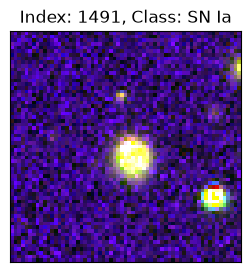

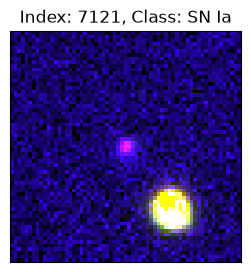

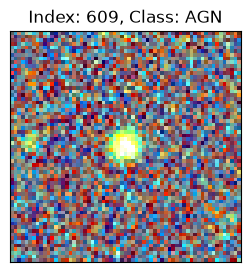

In [14]:
%matplotlib inline
import numpy as np
from IPython.display import display as ipy_display
rng = np.random.default_rng()
for i in rng.choice(len(ztf_dataset), size=3, replace=False):
    fig = ztf_dataset.display(i)
    ipy_display(fig)
    

## Supervised learning demo
The simplistic unsupervised HyraxAutoencoderV2 wasn't able to separate the classes in the data that was provided.
Let's try something else. 

Here is an example of wrapping a well established model (`ResNet18`) as a Hyrax model.

In [80]:
# Let's try wrapping RESNET18 as a Hyrax model and training it.
import torch
import torch.nn as nn
import torchvision.models as tv_models

from hyrax.models.model_registry import hyrax_model


@hyrax_model
class HyraxResNet18(nn.Module):
    """Wraps torchvision's ResNet18 as a Hyrax-compatible classifier."""

    def __init__(self, config, data_sample=None):
        super().__init__()
        self.config = config

        num_classes = len(CLASS_NAMES)
        in_channels = 3

        self.backbone = tv_models.resnet18()

        # Swap the classification head for number of classes
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, num_classes)

        # Manual optimizer/criterion — could instead be set via config for
        # Hyrax to build automatically
        # self.optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)
        # self.criterion = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.backbone(x)

    @staticmethod
    def prepare_inputs(data_dict):
        images = data_dict["data"]["image"]
        labels = data_dict["data"].get("target_as_one_hot", None)
        return images, labels

    def infer_batch(self, batch):
        images, _ = batch
        return self.forward(images)

    def train_batch(self, batch):
        images, labels = batch
        self.optimizer.zero_grad()
        logits = self.forward(images)
        loss = self.criterion(logits, labels)
        loss.backward()
        self.optimizer.step()
        preds = logits.argmax(dim=1)
        return {"loss": loss.item()}

    def validate_batch(self, batch):
        images, labels = batch
        logits = self.forward(images)
        loss = self.criterion(logits, labels)
        preds = logits.argmax(dim=1)
        return {"loss": loss.item()}

### Modify the data request

ResNet18 expects the labels to be provided as 1-hot lists, so we'll modify the data request that was used for training the HyraxAutoencoderV2 to request the additional field `target_as_one_hot`.

In [81]:
data_request = {
    "train": {
        "data": {
            "dataset_class": "LocalZTFAlertDataset",
            "data_location": "/work/nvme/bcrv/bborder/data/fixed_data",
            "primary_id_field": "obj_id",
            "fields": ["image", "target_as_one_hot"],
            "augment": ["image"],
        },
    },
    "validate": {
        "data": {
            "dataset_class": "LocalZTFAlertDataset",
            "data_location": "/work/nvme/bcrv/bborder/data/fixed_data",
            "primary_id_field": "obj_id",
            "fields": ["image", "target_as_one_hot"],
            "augment": ["image"]
        },
    },
}

h.set_config("data_request", data_request)

split = {
    "train": 0.8,
    "validate": 0.2,
}
h.set_config("split", split)

In [ ]:
h.set_config("model.name", "HyraxResNet18")
h.set_config("train.epochs", 10)
h.set_config("data_loader.batch_size", 64)

model = h.train()

In [84]:
data_request = {
    "infer": {
        "data": {
            "dataset_class": "LocalZTFAlertDataset",
            "data_location": "/work/nvme/bcrv/bborder/data/fixed_data",
            "primary_id_field": "obj_id",
            "fields": ["image"],
        },
    },
}

h.set_config("data_request", data_request)
h.set_config("data_loader.batch_size", 1024)

In [ ]:
inference_results = h.infer()

### Investigate results
As with the HyraxAutoencoderV2 model, we have trained and run inference with HyraxResNet18. (Please forgive me for using the same dataset for training and inference)

We'll define an exploration data request and build the arrays that are required to display a confusion matrix next.

In [86]:
# Do a simple confusion matrix here
from hyrax.config_utils import find_most_recent_results_dir

data_request_definition = {
    "explore": {
        "inference_results": {
            "dataset_class": "ResultDataset",
            "data_location": str(find_most_recent_results_dir(h.config, "infer")),
            "primary_id_field": "object_id",
            "fields": ["data"],
        },
        "ztf_data": {
            "dataset_class": "LocalZTFAlertDataset",
            "data_location": "/work/nvme/bcrv/bborder/data/fixed_data",
            "fields": ["image", "target", "target_friendly_name"],
        },
    },

}
h.set_config("data_request", data_request_definition)

[2026-07-29 17:25:14,443 hyrax.config_utils:WARNING] Runtime config contains key or section 'inference_results' which has no default defined. All configuration keys and sections must be defined in /u/drewoldag/.conda/envs/hyrax/lib/python3.13/site-packages/hyrax/hyrax_default_config.toml


In [88]:
import numpy as np
import pickle
from tqdm import tqdm

ds = h.prepare()

# Accumulate the predicted classes
predicted_classes = np.zeros(len(ds['explore'])).astype(int)
actual_classes = np.zeros(len(ds['explore'])).astype(int)
for i in tqdm(range(len(ds['explore']))):
    prediction = ds['explore'][i]['inference_results']['data']
    predicted_classes[i] = np.argmax(prediction)
    actual = ds['explore'][i]['ztf_data']['target']
    actual_classes[i] = actual


[2026-07-29 17:25:36,808 hyrax.verbs.prepare:INFO] Finished Prepare
100%|██████████| 9460/9460 [01:12<00:00, 130.41it/s]


## Deceptively good results
While the overall accuracy does look good here, if we look at the training and validation loss of the model during training, we can see that the model didn't really learn anything. 

Again, since the data is quite unbalanced, it's likely that HyraxResNet18 is able to guess the two common classes most of the time in order to get the accuracy reported. 


Accuracy for test dataset: 0.8482029598308668


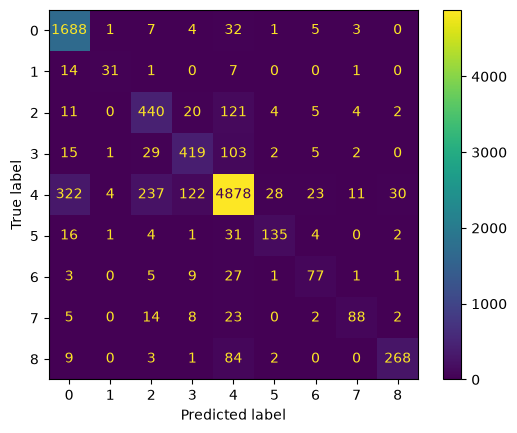

In [90]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

y_true = actual_classes.tolist()
y_pred = predicted_classes.tolist()

correct = 0
for t, p in zip(y_true, y_pred):
    correct += t == p

print("\nAccuracy for test dataset:", correct / len(y_true))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

## Conclusions

Neither of the models demonstrated in this notebook performed well. At the end of the day, high quality models wasn't the point.

What has been provided is a jumping off point for supervised and unsupervised learning using the provided ZTF dataset class for your work.
Use the funcionality of Hyrax to bookstrap your science so that you can focus on the interesting parts of the work - analysis, exploration and rapid development of new models. 